### 工作進度  
* 【置頂】**筆記內容架構**與**量化技術分析系統**相關資訊請參閱[251103筆記.ipynb](https://github.com/yilintung/StockInvestmentNotebook/blob/main/251103%E7%AD%86%E8%A8%98.ipynb)之「工作進度」。  
    - 「[股票投資筆記](https://github.com/yilintung/StockInvestmentNotebook)」預計下個月初重啟。  
    - 修改[解盤程序](https://github.com/yilintung/StockInvestmentNotebook/blob/main/mysys/StockAnalysis.py)，針對型態識別部分已做了調整；仍在進行修改中，因此今日執行解盤是開啟除錯模式（mysys.StockAnalysis(debug=True)）。  

* 引入模組與定義公用函式  

In [1]:
import numpy as np
import mysys
import markdown
import base64
from IPython.core.display import HTML

In [2]:
def stock_analysis( analysis, stock_id, buttom_pattern = False) :
    results,images = analysis.analysis(stock_id)
    if buttom_pattern is True and '底部型態' in images :
        print('底型反轉交易策略：')
        display(images['底部型態'])
    print('解盤內容：')
    if '整體評價' in images :
        display(images['整體評價'])
    result_md   = results.to_markdown(tablefmt="grid")
    result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
    display(HTML(result_html))

* 更新量化技術分析資料庫  

In [3]:
mysys.UpdatestockDatabase(prev_days=1)

2025-11-26 21:51:51.031 | INFO     | FinMind.data.finmind_api:get_data:158 - download TaiwanStockInfo, data_id: 


##### 更新台股總覽 #####
修改股票資訊。代碼 ＝ 1471：股票名稱 ＝ 首利，產業類別 ＝ 電子零組件業，類型 ＝ twse
修改股票資訊。代碼 ＝ 1598：股票名稱 ＝ 岱宇，產業類別 ＝ 化學生技醫療，類型 ＝ twse
修改股票資訊。代碼 ＝ 1710：股票名稱 ＝ 東聯，產業類別 ＝ 化學工業，類型 ＝ twse
修改股票資訊。代碼 ＝ 1712：股票名稱 ＝ 興農，產業類別 ＝ 化學工業，類型 ＝ twse
修改股票資訊。代碼 ＝ 1721：股票名稱 ＝ 三晃，產業類別 ＝ 化學生技醫療，類型 ＝ twse
修改股票資訊。代碼 ＝ 1732：股票名稱 ＝ 毛寶，產業類別 ＝ 化學工業，類型 ＝ twse
修改股票資訊。代碼 ＝ 1760：股票名稱 ＝ 寶齡富錦，產業類別 ＝ 化學生技醫療，類型 ＝ twse
修改股票資訊。代碼 ＝ 1786：股票名稱 ＝ 科妍，產業類別 ＝ 化學生技醫療，類型 ＝ twse
修改股票資訊。代碼 ＝ 2059：股票名稱 ＝ 川湖，產業類別 ＝ 電子零組件業，類型 ＝ twse
修改股票資訊。代碼 ＝ 2301：股票名稱 ＝ 光寶科，產業類別 ＝ 電子工業，類型 ＝ twse
修改股票資訊。代碼 ＝ 2303：股票名稱 ＝ 聯電，產業類別 ＝ 半導體業，類型 ＝ twse
修改股票資訊。代碼 ＝ 2315：股票名稱 ＝ 神達，產業類別 ＝ 電子工業，類型 ＝ twse
修改股票資訊。代碼 ＝ 2316：股票名稱 ＝ 楠梓電，產業類別 ＝ 電子零組件業，類型 ＝ twse
修改股票資訊。代碼 ＝ 2329：股票名稱 ＝ 華泰，產業類別 ＝ 電子工業，類型 ＝ twse
修改股票資訊。代碼 ＝ 2341：股票名稱 ＝ 英群，產業類別 ＝ 電子工業，類型 ＝ twse
修改股票資訊。代碼 ＝ 2342：股票名稱 ＝ 茂矽，產業類別 ＝ 電子工業，類型 ＝ twse
修改股票資訊。代碼 ＝ 2351：股票名稱 ＝ 順德，產業類別 ＝ 半導體業，類型 ＝ twse
修改股票資訊。代碼 ＝ 2353：股票名稱 ＝ 宏碁，產業類別 ＝ 電子工業，類型 ＝ twse
修改股票資訊。代碼 ＝ 2360：股票名稱 ＝ 致茂，產業類別 ＝ 電子工業，類型 ＝ twse
修改股票資訊。代碼 ＝ 2368：股票名稱 ＝ 金像電，產業類別

2025-11-26 21:51:57.323 | INFO     | FinMind.data.finmind_api:get_data:158 - download TaiwanStockPrice, data_id: 


日K：2025-11-26


* 建立「解盤」物件    

In [4]:
analysis = mysys.StockAnalysis(debug=True)

### 大盤解盤  

* 加權指數  

> **盤前**：[K線捕手十秒鐘看台股](https://www.facebook.com/kevinyang20180801/posts/pfbid0TcGLXydPvHTuxGonbsJkzXba1WKFwfeuWhHuWSd9Qyduz9KhxCkFumqvz1HC2bBAl)  
> 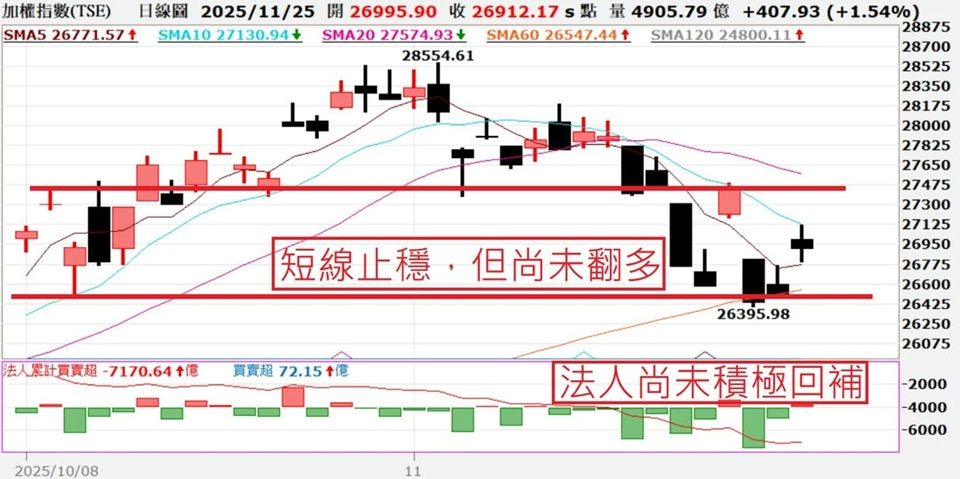  
>  
> **開盤**：加權指數上漲，持續反彈。  
> 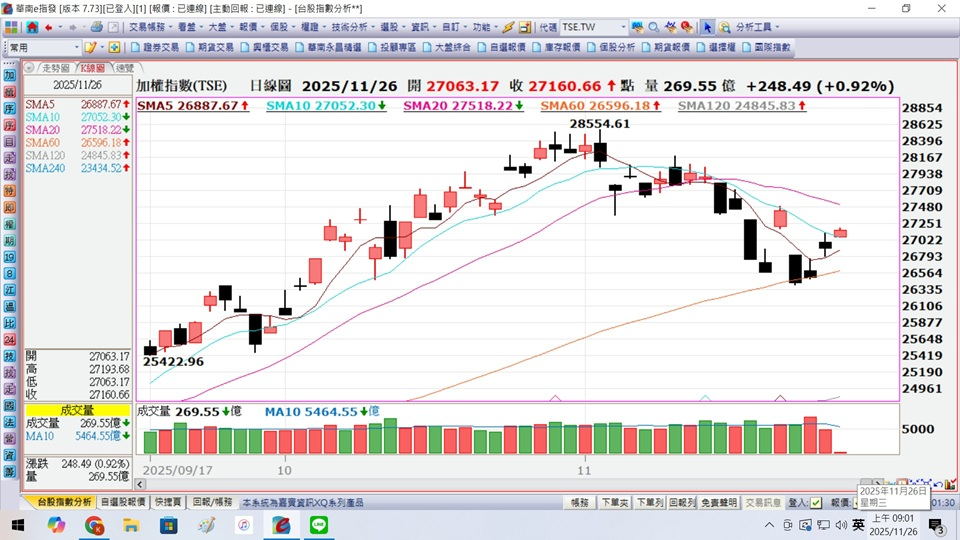  

> **盤後**：量化技術分析  

ＤＥＢＵＧ ： 日Ｋ開始日期 ＝ 2023-11-27 ，日Ｋ結束日期 ＝ 2025-11-26 ， 週Ｋ開始日期 ＝ 2023-11-27 ， 週Ｋ結束日期 ＝ 2025-11-17
ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'open_close', 'order': 5}]
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 17） 
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 36） 
ＤＥＢＵＧ ： 此轉折高點與底部型態之前高點間不足１５％空間，結束底部型態確認。此轉折點 ＝ 
Date     2025-05-16 00:00:00
Price               21843.69
Type                      HI
Name: 226, dtype: object
ＤＥＢＵＧ ： 底部型態開始索引 ＝ 200 （日期 ＝ 2025-04-09 ） ， 底部型態結束索引 ＝ 211 （日期 ＝ 2025-04-24 ）
ＤＥＢＵＧ ： 趨勢線開始索引 ＝ 0（價格資料開始索引 ＝ 200），趨勢線結束索引 ＝ 11（價格資料結束索引 ＝ 211）
ＤＥＢＵＧ ： 底部型態突破確認範圍 ： 211 ～ 231
ＤＥＢＵＧ ： 確認底部型態突破，收盤價超過頸線３％。價格索引 ＝ 216 ， 日期 ＝ 2025-05-02 ， 突破時頸線價格 ＝ 19758.63元 
ＤＥＢＵＧ ： 底部最低價格 ＝ 17391.76元 ； 估算目標價 ＝ 22257.56元
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 25 ，結束索引 ＝ 36） 
ＤＥＢＵＧ ： ★ 已達底部型態之目標價 ： 日期 ＝ 2025-06-10 （索引 ＝ 242）
ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'close', 'order': 10, 'smoothing': 5}, {'mode': 'open_close', 'order': 10}, {'mode': 'open_clo

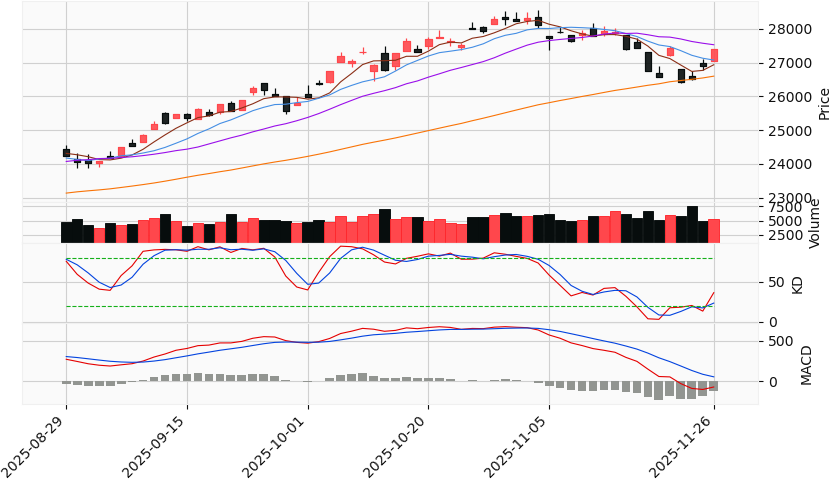

技術分析工具,解盤內容
Ｋ線／Ｋ棒,紡錘線 : 2025-11-25 孕育線／懷抱線 : 2025-11-24
Ｋ線圖,中期為中位階 長期為高位階
成交量,價量關係：未至大量門檻（成交量 ＝ 5235.32億元 ，十日均量 ＝ 5963.1億元）
型態,底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，2025-06-10時已達估算之目標價（22257.56點）。
移動平均線,5日線上揚、10日線下彎，短期盤整；20日線下彎、60日線上揚，中期盤整；120日線上揚、240日線上揚，長期翻多
ＫＤ指標,於2025-11-26黃金交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
週Ｋ－週ＫＤ指標,於2025-10-20當週死亡交叉。
整體評價,根據圖表分析： 價格趨勢 近期價格呈現回檔後的反彈跡象。K線圖顯示價格在經歷一段下跌後，近期有反彈的跡象，並且接近短期移動平均線。 價量關係 成交量在反彈時有所增加，顯示出市場對於價格回升的支持力度。這種價量配合通常是多頭的信號。 支撐與壓力 - 支撐位：短期支撐位可參考近期低點附近。 - 壓力位：壓力位則在接近20日移動平均線的位置，若能突破此壓力，則有望進一步上行。 KD指標解讀 KD指標顯示K線上穿D線，並從超賣區回升，這通常是買入信號，顯示出短期內可能有進一步上漲的空間。 MACD指標解讀 MACD指標顯示DIF線與MACD線的距離縮小，且柱狀體縮短，顯示出下跌動能減弱，可能出現反轉。 綜合評價 綜合以上分析，市場在經歷一段回檔後，出現反彈跡象，短期內有望進一步上行。建議投資者可考慮在支撐位附近進行佈局，並密切關注壓力位的突破情況。若價格能有效突破壓力位，則可考慮加碼持有。停損點可設在近期低點下方，以控制風險。


In [5]:
# 盤後：加權指數解盤
stock_analysis(analysis,'TAIEX')

* 櫃買指數  

> **開盤**：櫃買指數反彈到20日線反壓的位置。  
> 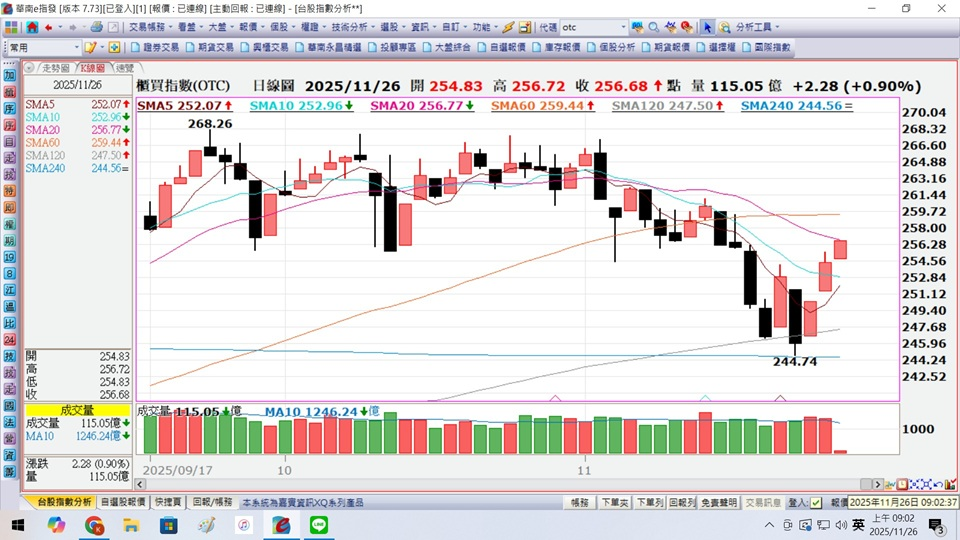  

> **盤後**：量化技術分析  

ＤＥＢＵＧ ： 日Ｋ開始日期 ＝ 2023-11-27 ，日Ｋ結束日期 ＝ 2025-11-26 ， 週Ｋ開始日期 ＝ 2023-11-27 ， 週Ｋ結束日期 ＝ 2025-11-17
ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'open_close', 'order': 5}]
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 15） 
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 35） 
ＤＥＢＵＧ ： 此轉折高點與底部型態之前高點間不足１５％空間，結束底部型態確認。此轉折點 ＝ 
Date     2025-05-15 00:00:00
Price                 231.51
Type                      HI
Name: 225, dtype: object
ＤＥＢＵＧ ： 底部型態開始索引 ＝ 200 （日期 ＝ 2025-04-09 ） ， 底部型態結束索引 ＝ 211 （日期 ＝ 2025-04-24 ）
ＤＥＢＵＧ ： 趨勢線開始索引 ＝ 0（價格資料開始索引 ＝ 200），趨勢線結束索引 ＝ 11（價格資料結束索引 ＝ 211）
ＤＥＢＵＧ ： 底部型態突破確認範圍 ： 211 ～ 231
ＤＥＢＵＧ ： 確認底部型態突破，收盤價超過頸線３％。價格索引 ＝ 216 ， 日期 ＝ 2025-05-02 ， 突破時頸線價格 ＝ 216.44元 
ＤＥＢＵＧ ： 底部最低價格 ＝ 185.14元 ； 估算目標價 ＝ 247.79元
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 22 ，結束索引 ＝ 35） 
ＤＥＢＵＧ ： ★ 已達底部型態之目標價 ： 日期 ＝ 2025-08-18 （索引 ＝ 291）
ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'close', 'order': 10, 'smoothing': 5}, {'mode': 'open_close', 'order': 10}, {'mode': 'open_close', '

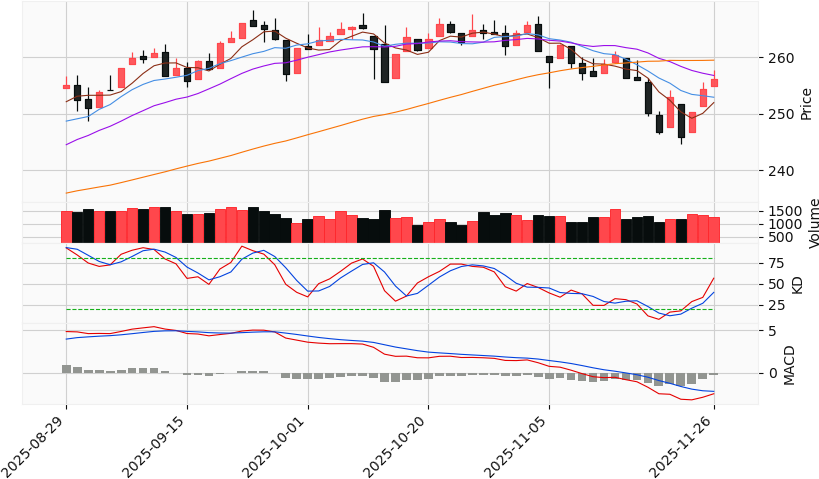

技術分析工具,解盤內容
Ｋ線／Ｋ棒,（未識別出Ｋ線型態）
Ｋ線圖,中期為中位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 1242.92億元 ，十日均量 ＝ 1269.24億元）
型態,底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，2025-08-18時已達估算之目標價（247.79點）。
移動平均線,5日線上揚、10日線下彎，短期盤整；20日線下彎、60日線上揚，中期盤整；120日線上揚、240日線走平，長期盤整
ＫＤ指標,於2025-11-20黃金交叉。
ＭＡＣＤ指標,MACD在零軸以下，中期空方
週Ｋ－週ＫＤ指標,於2025-09-22當週死亡交叉。
整體評價,技術分析 價格趨勢 近期價格呈現反彈走勢，從低點回升，並突破短期移動平均線。整體趨勢由下跌轉為盤整，並有上漲的跡象。 價量關係 成交量在價格反彈時有所增加，顯示出多頭力量的增強。這種價量配合支持短期上漲趨勢。 支撐與壓力 - 支撐位：250點附近，為近期低點及短期移動平均線的支撐。 - 壓力位：260點附近，為中期移動平均線及前期高點的壓力。 KD指標解讀 KD指標顯示K線上穿D線，並從超賣區回升，顯示出買盤力量增強，短期內有進一步上漲的可能。 MACD指標解讀 MACD指標的DIF線與MACD線距離縮小，柱狀體由負轉正，顯示出下跌動能減弱，市場有轉強的跡象。 綜合評價 目前市場由下跌轉為盤整，並有上漲的潛力。短期內若能突破260點壓力位，則有望進一步上漲。建議投資者可考慮在支撐位附近進行佈局，並在壓力位附近考慮停利。注意市場波動，設置適當的停損點以控制風險。


In [6]:
# 盤後：櫃買指數解盤
stock_analysis(analysis,'TPEx')

### 個股觀察  

* 聚陽(1477)  
  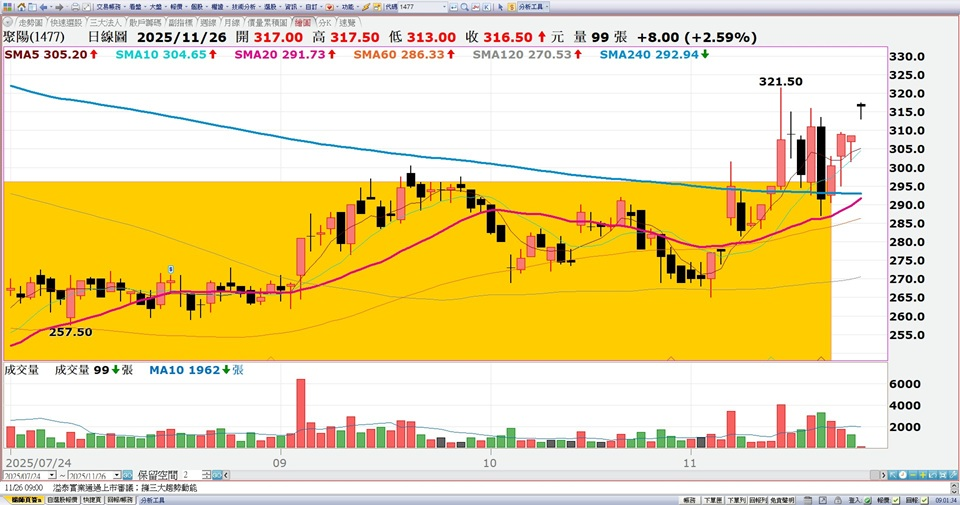  
* 光聖(6442)  
  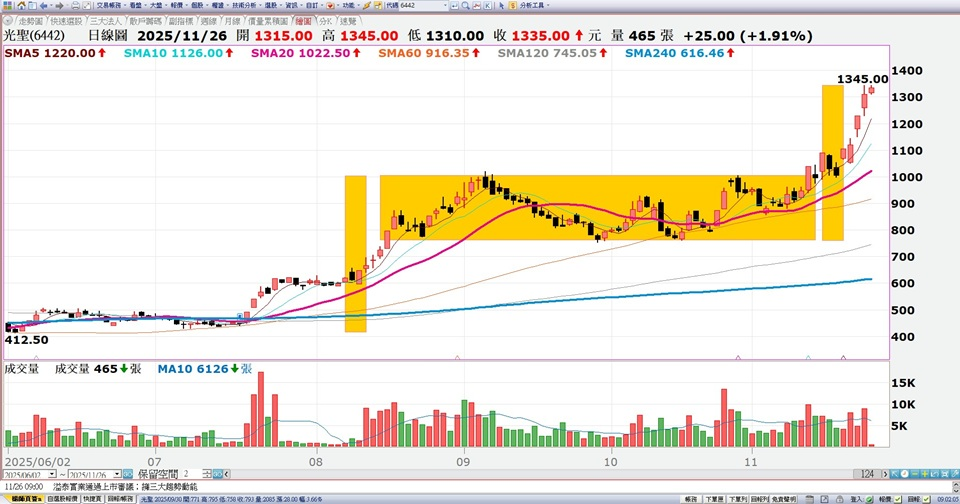  
* 金像電(2368)  
  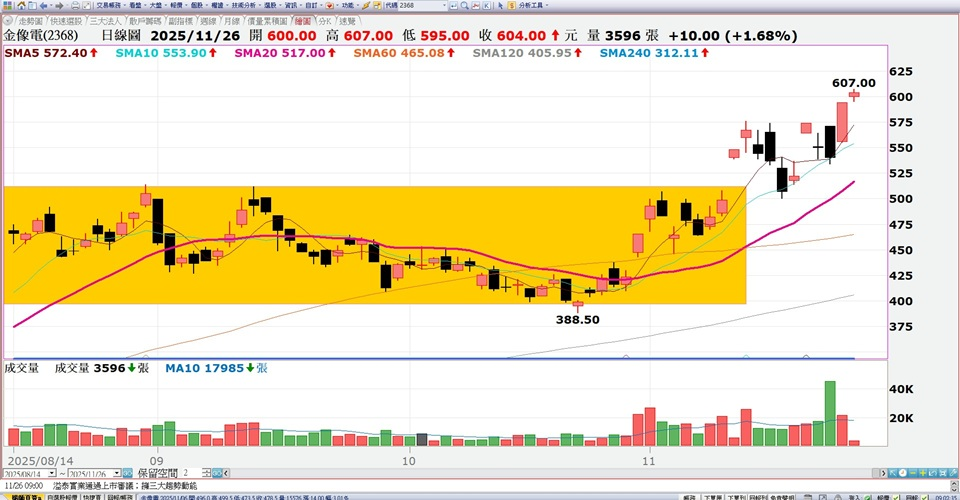  
* 裕民(2606)  
  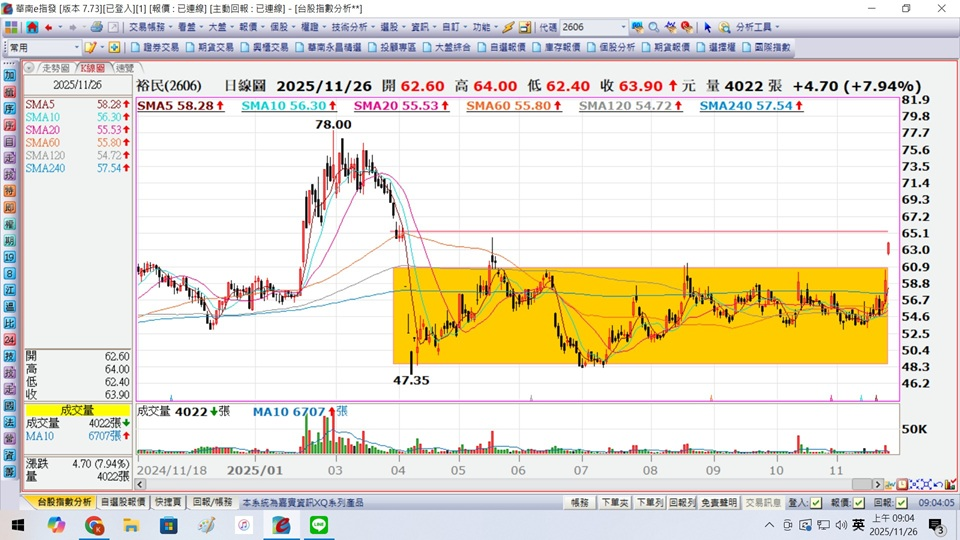  
* 慧洋-KY(2637)  
  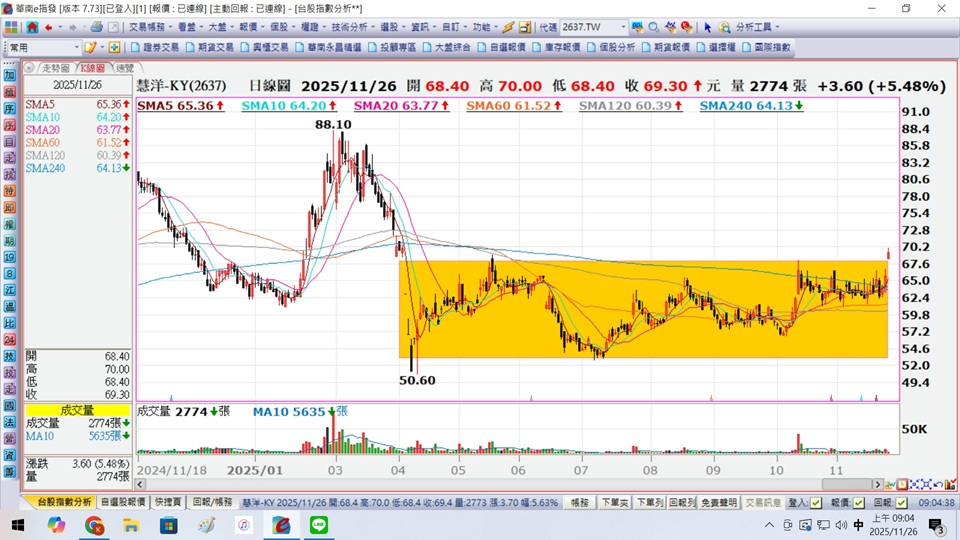  
* 富邦美債20年(00696B)  
  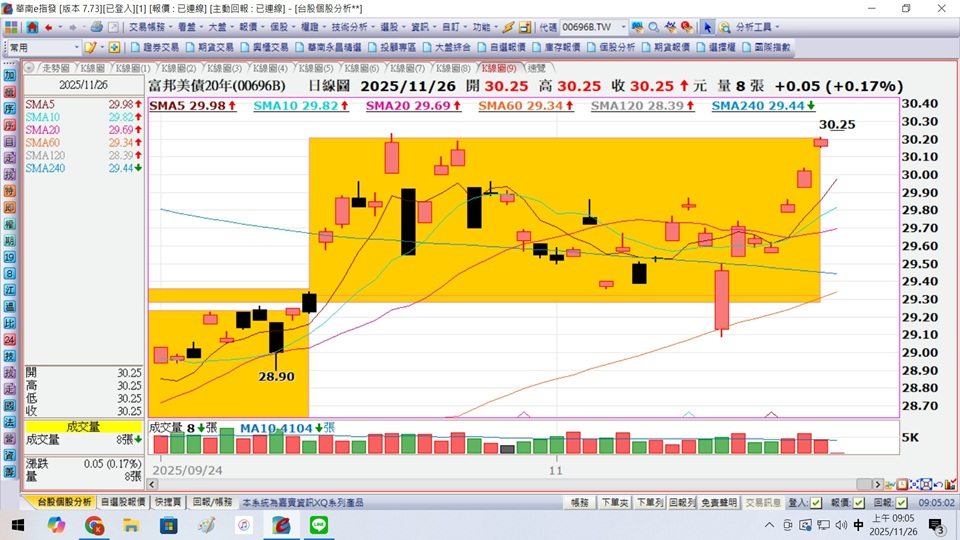  
* 環科(2413)  
  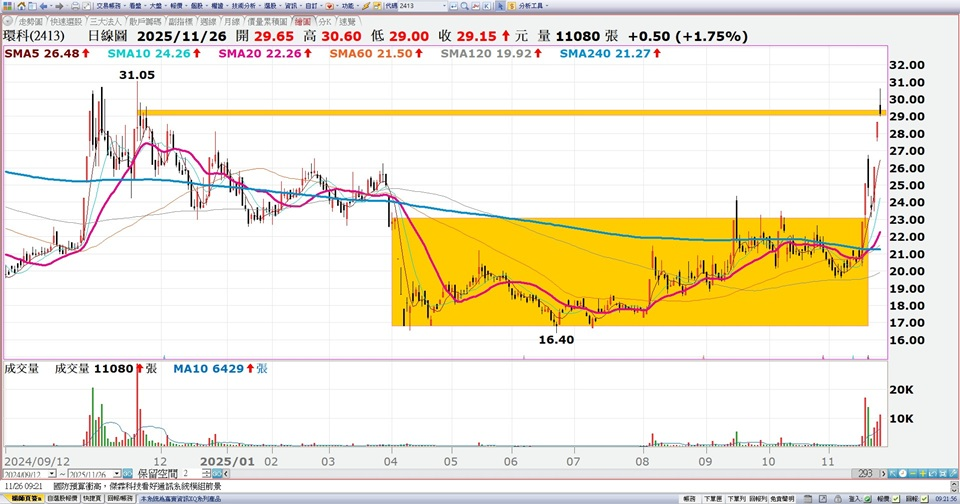  
* 兆赫(2485)  
  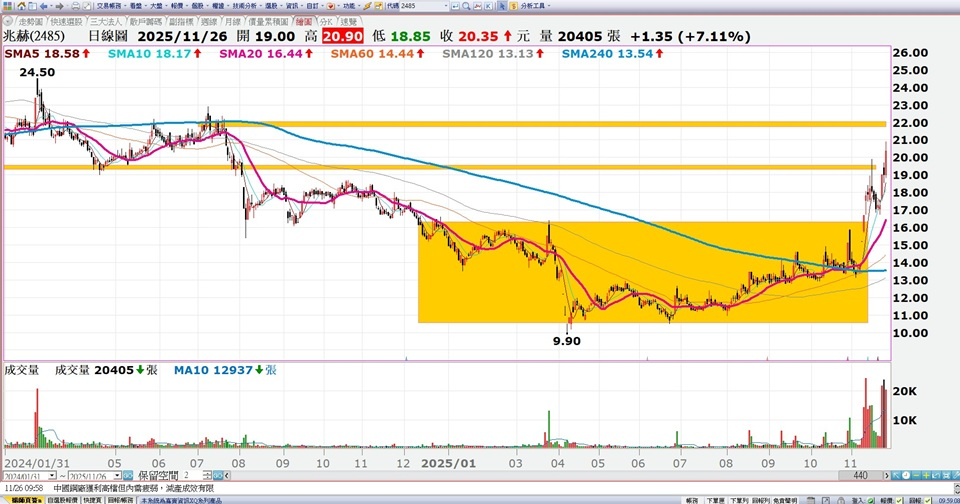  
* 來億-KY(6890)  
  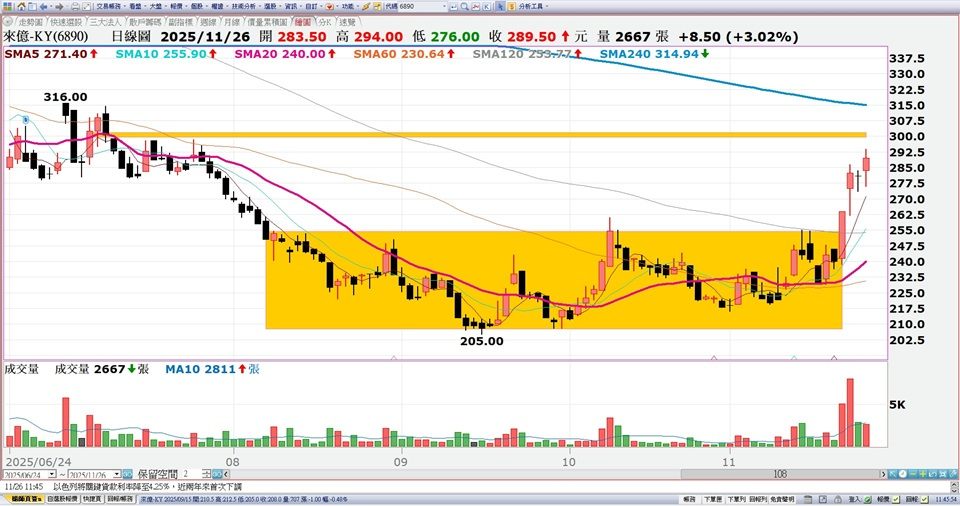  

### 個股解盤  

* 恆大(1325)  
  看法：跌破頸線後反彈，尚未站上頸線。           

> **盤後**：量化技術分析  

ＤＥＢＵＧ ： 日Ｋ開始日期 ＝ 2023-11-27 ，日Ｋ結束日期 ＝ 2025-11-26 ， 週Ｋ開始日期 ＝ 2023-11-27 ， 週Ｋ結束日期 ＝ 2025-11-17
ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'open_close', 'order': 5}]
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 14） 
ＤＥＢＵＧ ： 此轉折高點超過底部型態之前高點，結束底部型態確認。此轉折點 ＝ 
Date     2025-01-10 00:00:00
Price                   39.5
Type                      HI
Name: 147, dtype: object
ＤＥＢＵＧ ： 底部型態開始索引 ＝ 40 （日期 ＝ 2024-08-06 ） ， 底部型態結束索引 ＝ 137 （日期 ＝ 2024-12-26 ）
ＤＥＢＵＧ ： 趨勢線開始索引 ＝ 0（價格資料開始索引 ＝ 40），趨勢線結束索引 ＝ 97（價格資料結束索引 ＝ 137）
ＤＥＢＵＧ ： 頸線角度（絕對值）26.11°過大，改用直線頸線（斜率 ＝ 0.00，截距 ＝ 30.25）
ＤＥＢＵＧ ： 底部型態突破確認範圍 ： 137 ～ 157
ＤＥＢＵＧ ： 確認底部型態突破，收盤價超過頸線３％。價格索引 ＝ 142 ， 日期 ＝ 2025-01-03 ， 突破時頸線價格 ＝ 30.25元 
ＤＥＢＵＧ ： 底部最低價格 ＝ 24.75元 ； 估算目標價 ＝ 35.75元
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 6 ，結束索引 ＝ 14） 
ＤＥＢＵＧ ： 底部型態開始索引 ＝ 271 （日期 ＝ 2025-07-21 ） ， 底部型態結束索引 ＝ 356 （日期 ＝ 2025-11-21 ）
ＤＥＢＵＧ ： 趨勢線開始索引 ＝ 0（價格資料開始索引 ＝ 271），趨勢線結束索引 ＝ 85（價格資料結束索引 ＝ 356）
ＤＥＢＵＧ ： 頸線角度（絕對值）20.73°過大，改用直線頸線（斜率 ＝ 0.00，截距 ＝ 31.85）
ＤＥＢＵＧ ： 底部型態突破確認範圍 ： 356 ～ 

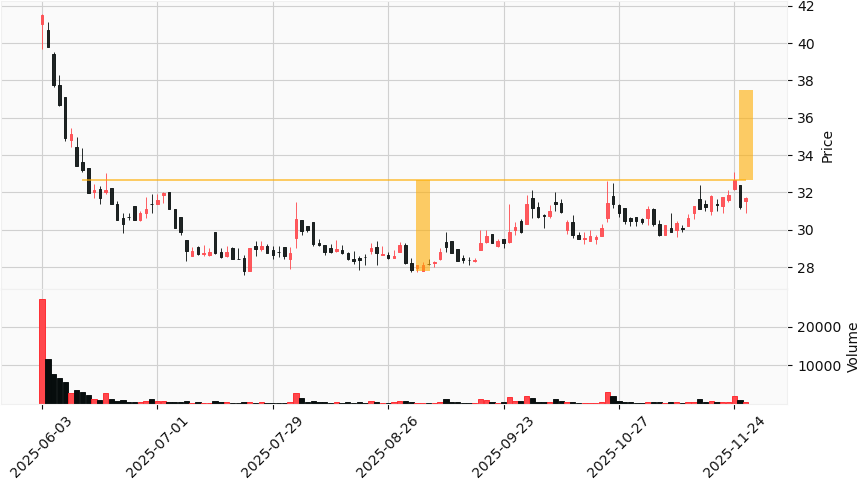

解盤內容：


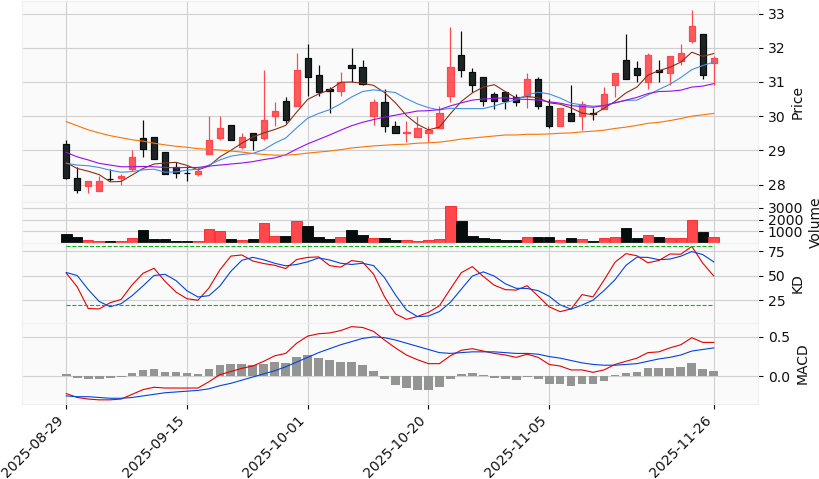

技術分析工具,解盤內容
Ｋ線／Ｋ棒,吞噬 : 2025-11-20 孕育線／懷抱線 : 2025-11-26
Ｋ線圖,中期為高位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 514張 ，十日均量 ＝ 764張）
型態,尚未成形底型反轉之底部型態，型態範圍由2025-06-12開始到2025-11-26結束。
移動平均線,5日線上揚、10日線上揚，短期翻多；20日線上揚、60日線上揚，中期翻多；120日線下彎、240日線上揚，長期盤整
ＫＤ指標,於2025-11-25死亡交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
週Ｋ－週ＫＤ指標,於2025-11-17當週黃金交叉。
整體評價,根據圖表分析，以下是對當前市場狀況的技術分析： 價格趨勢 近期價格呈現震盪走勢，雖然有上漲的跡象，但在高點附近出現回檔。短期移動平均線（5日和10日）在價格下方，顯示短期仍有支撐，但需要注意價格是否能持續站穩在這些均線之上。 價量關係 成交量在近期高點時顯著增加，顯示出多頭的強勁動能，但隨後的回檔伴隨著成交量的減少，表明市場可能進入觀望狀態。 支撐與壓力 支撐位可觀察在31元附近，這是近期價格多次測試的低點。壓力位則在32.5元左右，為近期高點。 KD指標 KD指標顯示K線已經從超買區回落，並且D線也在下降，這可能預示著短期內價格有進一步回檔的風險。 MACD指標 MACD指標顯示紅色柱體縮短，DIF線和MACD線接近，顯示多頭動能減弱，需警惕可能的趨勢反轉。 綜合評價 整體來看，市場目前處於震盪整理階段，短期內可能會有回檔壓力。建議投資者謹慎觀望，等待價格在支撐位的表現，若能有效支撐並伴隨成交量放大，則可考慮進場。若價格跌破支撐位，則需考慮停損。


In [7]:
stock_analysis(analysis,'1325',buttom_pattern=True)

> **盤後**：底部反轉交易策略分析    

In [8]:
def line_drawing_callback( range_prices) :
    # 設定頸線
    neckline_start_date = '2025-06-12'
    neckline_end_date   = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    neckline_price      = range_prices.loc['2025-07-03']['Open']

    # 設定底部日期與價格
    bottom_date  = '2025-07-22'
    bottom_price = range_prices.loc['2025-07-22']['Close']

    # 估算目標價
    target_price = (neckline_price - bottom_price) + neckline_price

    print('估算目標價為{:.2f}元'.format(target_price))

    # 設定突破日期
    breakout_date = '2025-11-24'
    
    seq_of_seq_of_points=[
        [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)],
        [(bottom_date,bottom_price),(bottom_date,neckline_price)],
        [(breakout_date,neckline_price),(breakout_date,target_price)]
    ]

    linewidths=[2.0,15.0,15.0]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow','xkcd:orange yellow']

    return seq_of_seq_of_points,linewidths,colors

估算目標價為36.20元


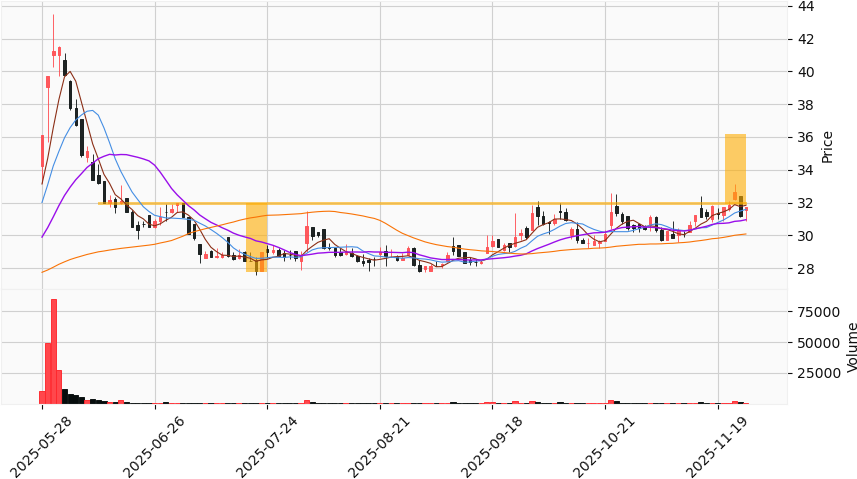

In [9]:
image = mysys.DrawOnKlineChart('1325','2025-05-28','2025-11-26',line_drawing_callback)
display(image)

籌碼面：  
法人小買(+114)：外資小買(+113)、投信中立(0)、自營小買(+1)。  
主力小買(+26)。  
分公司買賣家數差集中(+18)。  
融資中立(-3)、融券增(+19)。  